In [ ]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as display
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,f1_score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#Naming the columns
columns=['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level']


In [ ]:
#Loading Dataset
train_path=r"/content/drive/MyDrive/NSL-KDD_Dataset/KDDTrain+.txt"
train_df=pd.read_csv(train_path,delimiter=",")

test_path=r"/content/drive/MyDrive/NSL-KDD_Dataset/KDDTest+.txt"
test_df=pd.read_csv(test_path,delimiter=",")

In [ ]:
train_df.columns=columns
test_df.columns=columns

In [ ]:
train_df.drop(['level'],axis=1,inplace=True)
test_df.drop(['level'],axis=1,inplace=True)

In [ ]:
# No of rows
print("NO OF Train ROWS:")
print(len(train_df))

print("NO OF Test ROWS:")
print(len(test_df))

NO OF Train ROWS:
125972
NO OF Test ROWS:
22543


In [ ]:
#No of Unique Labels
print('NO OF UNIQUE LABELS:')
labels=train_df.iloc[:,-1]
print(labels.unique())
# or train_df['outcome'].unique()

NO OF UNIQUE LABELS:
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [ ]:
#Top 5 freq attack type
print('Top 5 Frequent attack types:')
print(labels.value_counts().head(5))

Top 5 Frequent attack types:
outcome
normal       67342
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
Name: count, dtype: int64


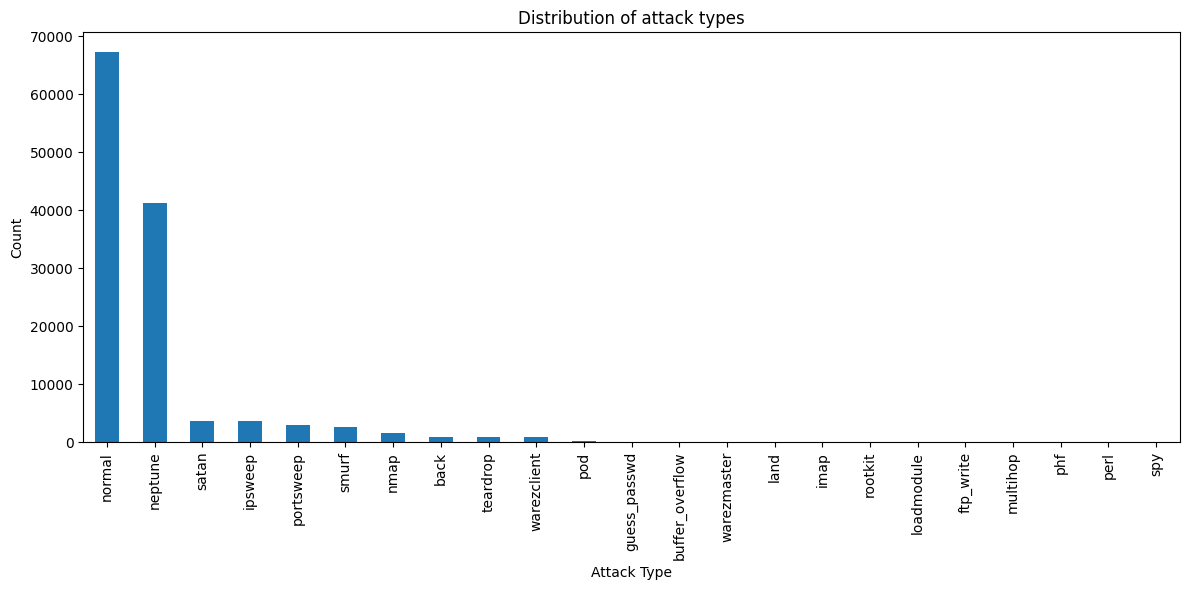

In [ ]:
#Bar chart showing distribution of attack types.
label_count=labels.value_counts()
plt.figure(figsize=(12,6))
label_count.plot(kind='bar')
plt.title('Distribution of attack types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
#Basic inspection
print('First 5 rows of train data:')
train_df.head()

First 5 rows of train data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal
1,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune
2,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal
3,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal
4,0,tcp,private,REJ,0,0,0,0,0,0,...,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune


In [ ]:
print('First 5 rows of test data:')
test_df.head()

First 5 rows of test data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan
4,0,tcp,http,SF,267,14515,0,0,0,0,...,255,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal


In [ ]:
print('Last 5 rows of train data:')
train_df.tail()

Last 5 rows of train data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
125967,0,tcp,private,S0,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune
125968,8,udp,private,SF,105,145,0,0,0,0,...,244,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,30,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune
125971,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,77,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal


In [ ]:
print('Last 5 rows of test data:')
test_df.tail()

Last 5 rows of test data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,141,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal
22539,0,tcp,http,SF,317,938,0,0,0,0,...,255,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,255,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,252,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal
22542,0,tcp,sunrpc,REJ,0,0,0,0,0,0,...,21,0.08,0.03,0.00,0.00,0.00,0.0,0.44,1.00,mscan


In [ ]:
print('Structure of dataset')
train_df.info()

Structure of dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 n

In [ ]:
print('Statistical summary')
train_df.describe()

Statistical summary


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125972.000000,1.259720e+05,1.259720e+05,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,...,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,4.556710e+04,1.977927e+04,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,...,182.149200,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241
std,2604.525522,5.870354e+06,4.021285e+06,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,...,99.206565,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#Feature types
print('Feature types:')
print(train_df.dtypes)

Feature types:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror

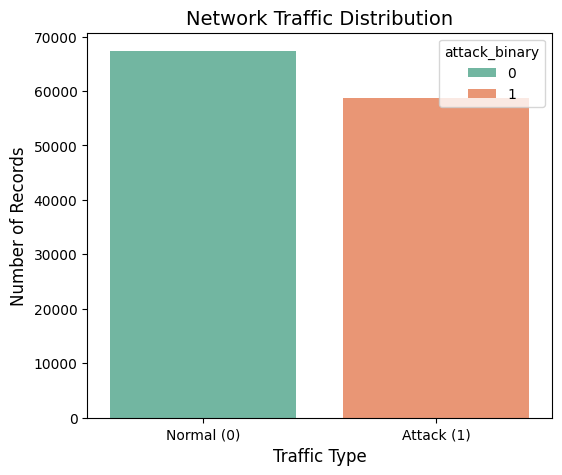

Class Distribution (%):
 attack_binary
0    53.457911
1    46.542089
Name: proportion, dtype: float64


In [ ]:
# Create binary target for both train and test sets
for df in [train_df, test_df]:
    df['attack_binary'] = df['outcome'].apply(lambda x: 0 if x.lower() == 'normal' else 1)

# Plot class distribution (with labels)
plt.figure(figsize=(6, 5))
sns.countplot(x='attack_binary', hue='attack_binary', data=train_df, palette='Set2')
plt.title('Network Traffic Distribution', fontsize=14)
plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks([0, 1], ['Normal (0)', 'Attack (1)'])
plt.show()

# Show exact percentages
class_dist = train_df['attack_binary'].value_counts(normalize=True) * 100
print("Class Distribution (%):\n", class_dist)

In [ ]:
#Identify categorical vs. numerical features
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_features = train_df.select_dtypes(exclude=['object']).columns.tolist()
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['protocol_type', 'service', 'flag', 'outcome']
Numerical Features: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_binary']


In [ ]:
#Checking for missing values and duplicates
#Missing values
print("Missing values per column:")
print(train_df.isnull().sum())

Missing values per column:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate   

In [ ]:
#For duplicates
num_duplicates = train_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [ ]:
#Create a schema mapping table
binary = {"land","logged_in","root_shell","su_attempted","is_host_login","is_guest_login"}
drop = {"num_outbound_cmds","is_host_login","level"}
special = {"src_bytes":"Log-transform + Normalize","dst_bytes":"Log-transform + Normalize"}
labels = {"outcome":"Label encode","category":"Label encode"}
def infer_type(col, s):
    if col in binary: return "Binary"
    if s.dtype=="object": return "Categorical"
    return "Numerical"
def preprocessing(col, t):
    if col in drop: return "Drop"
    if col in special: return special[col]
    if col in labels: return labels[col]
    if t=="Binary": return "Keep as is (0/1)"
    if t=="Categorical": return "One-hot encode / Label encode"
    if t=="Numerical": return "Already normalized" if "_rate" in col else "Normalize/Standardize"
    return "Check"
schema = [{"Feature":c,
           "Type":infer_type(c,train_df[c]),
           "Preprocessing":preprocessing(c,infer_type(c,train_df[c])),
           "Semantic":"Label" if c in ["outcome","category"] else "Feature"}
          for c in train_df.columns]
schema_df = pd.DataFrame(schema)
display.display(schema_df)

,Feature,Type,Preprocessing,Semantic
0,duration,Numerical,Normalize/Standardize,Feature
1,protocol_type,Categorical,One-hot encode / Label encode,Feature
2,service,Categorical,One-hot encode / Label encode,Feature
3,flag,Categorical,One-hot encode / Label encode,Feature
4,src_bytes,Numerical,Log-transform + Normalize,Feature
5,dst_bytes,Numerical,Log-transform + Normalize,Feature
6,land,Binary,Keep as is (0/1),Feature
7,wrong_fragment,Numerical,Normalize/Standardize,Feature
8,urgent,Numerical,Normalize/Standardize,Feature
9,hot,Numerical,Normalize/Standardize,Feature


In [ ]:
#Identify and handle missing values in NSL-KDD dataset
for col in train_df.columns:
    if train_df[col].isnull().sum() > 0:
        if train_df[col].dtype == 'object':
            train_df[col].fillna(train_df[col].mode()[0], inplace=True)
        else:
            train_df[col].fillna(train_df[col].median(), inplace=True)
print("Missing values handled.")

Missing values handled.


In [ ]:
#Remove Duplicate Rows
train_df = train_df.drop_duplicates()
print("Duplicates removed. Current shape:", train_df.shape)

Duplicates removed. Current shape: (125972, 43)


In [ ]:
#Encoding categorical features using one-hot encoding
le = LabelEncoder()
train_df['outcome'] = le.fit_transform(train_df['outcome'])

encoded_df = pd.get_dummies(train_df[['protocol_type','service','flag']], drop_first=True)
train_df=pd.concat([train_df,encoded_df],axis=1)
train_df=train_df.drop(columns=['protocol_type','service','flag'])
print("Categorical features encoded. Current shape:", train_df.shape)

Categorical features encoded. Current shape: (125972, 121)


In [ ]:
# Separate features and target
X = train_df.drop(columns=['outcome'])
y = train_df['outcome']
#Scale numerical features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
train_df = pd.DataFrame(X_scaled, columns=X.columns)
train_df['outcome'] = y
print("Numerical features scaled.")

Numerical features scaled.


In [ ]:
#  Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (88180, 120)
Testing set shape: (37792, 120)


In [ ]:
# Find classes with more than 1 sample
valid_classes = y_train.value_counts()[y_train.value_counts() > 1].index

# Keep only those classes
mask = y_train.isin(valid_classes)
X_train_filtered, y_train_filtered = X_train[mask], y_train[mask]

print("Before:", X_train.shape, "After filtering:", X_train_filtered.shape)

# Now apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = smote.fit_resample(X_train_filtered, y_train_filtered)
print("After SMOTE:", X_train_res.shape)


Before: (88180, 120) After filtering: (88179, 120)
After SMOTE: (1037058, 120)


In [ ]:
# Implementing Logistic Regression
lr = LogisticRegression(max_iter=500,class_weight='balanced')
lr.fit(X_train_res, y_train_res)

y_pred_lr= lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9973803979678239
Logistic Regression Macro F1: 0.7430260745398635
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       287
           1       0.35      0.78      0.48         9
           2       0.00      0.00      0.00         2
           3       1.00      0.94      0.97        16
           4       0.60      1.00      0.75         3
           5       0.99      0.98      0.98      1080
           6       1.00      1.00      1.00         5
           7       0.00      0.00      0.00         3
           8       0.50      1.00      0.67         2
           9       1.00      1.00      1.00     12364
          10       0.93      0.97      0.95       448
          11       1.00      1.00      1.00     20203
          12       0.50      1.00      0.67         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00        60
          15       1.00      0.99    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9993120237087214
Random Forest Macro F1: 0.7855694053564128
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       287
           1       0.69      1.00      0.82         9
           2       0.00      0.00      0.00         2
           3       1.00      0.94      0.97        16
           4       1.00      1.00      1.00         3
           5       1.00      0.99      0.99      1080
           6       0.83      1.00      0.91         5
           7       0.00      0.00      0.00         3
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00     12364
          10       0.98      1.00      0.99       448
          11       1.00      1.00      1.00     20203
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00        60
          15       1.00      1.00      1.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Decision Tree Classifier
dt_res = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=None)
dt_res.fit(X_train_res, y_train_res)

y_pred_dt_res = dt_res.predict(X_test)
print("\nDecision Tree (SMOTE) Accuracy:", accuracy_score(y_test, y_pred_dt_res))
print("Decision Tree (SMOTE) Macro F1:", f1_score(y_test, y_pred_dt_res, average="macro"))
print(classification_report(y_test, y_pred_dt_res))


Decision Tree (SMOTE) Accuracy: 0.9988886536833192
Decision Tree (SMOTE) Macro F1: 0.8215908671758616
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       287
           1       1.00      0.78      0.88         9
           2       0.33      0.50      0.40         2
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00         3
           5       1.00      0.99      0.99      1080
           6       1.00      1.00      1.00         5
           7       0.00      0.00      0.00         3
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00     12364
          10       0.98      0.99      0.98       448
          11       1.00      1.00      1.00     20203
          12       0.50      1.00      0.67         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00        60
          15       0.99      1.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
